# 02 - Graph construction

In this notebook we turn the scheduled stop sequences into the graph we will analyze. A node is a stop incident to at least one scheduled segment. We create a directed edge `u -> v` when a trip visits `v` immediately after `u`, and its weight is the number of trip sequences containing that ordered pair. The main job is one streaming pass over the 816 MB, roughly 15.7-million-row `stop_times.txt` file, so we never need the entire table in memory.

**Question for this stage:** *What exact graph follows from the GTFS stop sequences, and are the file-order assumptions strong enough for a streaming build?* Centrality, communities, and removal simulations will all inherit the node, edge, and weight definitions we choose here, so we spell them out and test the implementation on a small example first.

## Input

- `outputs/nb/01_data_preparation/tables/stops_clean.csv` - stop attributes after cleaning (name, lat/lon, district, metropolitan area). Produced by the `01_data_preparation` notebook.
- `israel-public-transportation/stop_times.txt` - the raw GTFS stop-times feed. At 816 MB it isn't tracked under git; it's downloaded on demand from Google Drive by one of the cells below.

## Output (all under `outputs/nb/02_graph_construction/`)

| Path | Contents |
|---|---|
| `graph_directed.pkl` | `networkx.DiGraph` - trip-adjacency graph, edge attribute `weight` = number of trips per segment |
| `graph_undirected.pkl` | `networkx.Graph` - the undirected projection, `weight` = sum of both directions |
| `tables/nodes.csv` | one row per node, with its stop attributes |
| `tables/edges.csv` | one row per directed segment, with `trip_frequency` |
| `tables/top_segments.csv` | the busiest segments, for a quick sanity check |
| `tables/graph_build_summary.json` | node/edge counts, density, build statistics, data-integrity counters |
| `figures/top_segments.png`, `figures/weight_distribution.png` | sanity-check figures |

The undirected pickle will be the main input for connectivity analysis; we keep the directed version for measures where service direction matters.

## Setting up the working environment

We begin with the shared environment setup. It locates the GTFS folder by walking upward from the current directory, or clones the project into `/content` for a fresh Colab run. It then changes to the repository root, defines `DATA` and `OUT`, and creates the shared output folder. `_ensure(...)` only installs imports that are missing, so rerunning an already configured environment is quick.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## Libraries, stage directories, and cost controls

We use pandas for saved tables, NetworkX for graph objects, and Matplotlib for the diagnostic figures. The large stop-times pass uses Python's `csv` reader because it yields one record at a time and keeps memory use tied to the segment dictionary rather than the source file size.

The runtime settings are:

- `SORT_CHECK_ROWS = 500_000` controls the early ordering sample. Raising it checks more of the file before the full pass.
- `PROGRESS_EVERY = 2_000_000` only controls progress messages.
- `FULL_INTEGRITY_CHECK = True` counts ordering violations during the complete stream. It costs one extra integer parse per row but gives us a full-file check instead of relying only on the sample.

This cell also creates the stage folders, sets display options, and raises `csv.field_size_limit` so unusually long records do not stop the parser.

In [2]:
_ensure("pandas", "networkx", "matplotlib")

import csv, json, pickle, time
from collections import defaultdict

import pandas as pd
import networkx as nx

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

# ---- cost knobs (see markdown above) ----
SORT_CHECK_ROWS = 500_000        # rows sampled by the ordering-verification pass
PROGRESS_EVERY = 2_000_000       # progress print interval in the main streaming pass
FULL_INTEGRITY_CHECK = True      # track ordering violations over the whole file too

# ---- this stage's own output folder ----
STAGE = OUT / "02_graph_construction"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("pandas", pd.__version__, "| networkx", nx.__version__)
print("Stage output folder:", STAGE)

pandas 3.0.5 | networkx 3.6.1
Stage output folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction


## The formal model of the graph

We want the graph definition fixed before writing the streaming code.

Let $T$ be the set of trips in the GTFS feed. Each trip $t \in T$ is an ordered sequence of stop visits

$$t = \left( s^{t}_{1},\, s^{t}_{2},\, \dots,\, s^{t}_{k_t} \right),$$

where $s^{t}_{i}$ is the stop served at position $i$ of the trip (position = the GTFS `stop_sequence` field), and $k_t$ is the number of stops on that trip.

We define the weighted trip-adjacency graph

$$G = (V,\, E,\, W)$$

- **Nodes.** $V = \{\, v : v \text{ is a stop incident to at least one segment} \,\}$. Concretely, a stop is a node if some trip enters it or leaves it. A stop that appears in the feed but never has a predecessor and never has a successor (a degenerate single-stop trip) is not a node - see the note on isolated stops below.
- **Edges.** $E \subseteq V \times V$, where
  $$ (u,v) \in E \iff \exists\, t \in T,\ \exists\, i < k_t : \ s^{t}_{i} = u \ \wedge\ s^{t}_{i+1} = v \ \wedge\ u \neq v .$$
  In words: an edge exists exactly when some trip goes from $u$ directly to $v$ with no stop in between. This is a service relation, not a geographic one - two stops 50 m apart with no line connecting them are not connected.
- **Weights.** $W : E \to \mathbb{N}$, where
  $$ W(u,v) = \left| \{\, (t,i) \ : \ s^{t}_{i} = u,\ s^{t}_{i+1} = v \,\} \right| ,$$
  that is, the number of trips using the segment $u \to v$. The weight is therefore a measure of frequency / capacity: a high weight means many service trips run over that connection each day.

### The undirected projection

For connectivity, communities, and node-removal analysis we also need the undirected projection $\tilde{G} = (V, \tilde{E}, \tilde{W})$ where

$$ \{u,v\} \in \tilde{E} \iff (u,v) \in E \ \vee\ (v,u) \in E, \qquad \tilde{W}(\{u,v\}) = W(u,v) + W(v,u) $$

(a missing direction contributes $0$). We sum rather than average or take the maximum so an undirected weight still means the total number of scheduled trip traversals across that stop pair.

### A worked example

Three trips over four stops $A, B, C, D$:

| Trip | Stop sequence |
|---|---|
| $t_1$ | $A \to B \to C$ |
| $t_2$ | $A \to B \to D$ |
| $t_3$ | $C \to B \to A$ |

The directed graph: $V = \{A,B,C,D\}$ and

$$E = \{(A,B), (B,C), (B,D), (C,B), (B,A)\}, \quad W(A,B) = 2,\ W(B,C) = W(B,D) = W(C,B) = W(B,A) = 1 .$$

The undirected projection: $\tilde{E} = \{\{A,B\}, \{B,C\}, \{B,D\}\}$ where

$$\tilde{W}(\{A,B\}) = W(A,B) + W(B,A) = 2 + 1 = 3, \quad \tilde{W}(\{B,C\}) = 1 + 1 = 2, \quad \tilde{W}(\{B,D\}) = 1 + 0 = 1 .$$

In the toy graph, $B$ has three neighbors while $A$, $C$, and $D$ have one each. This gives us an easy expected topology and expected weights for testing both conversion functions.

### Modeling decisions we are making

1. We drop self-loops. Consecutive duplicate stops do appear in the feed, but an edge $u \to u$ does not add reachability information. We count every skipped instance.
2. Weights count scheduled trip occurrences, not passengers or vehicle capacity. This is a supply-frequency measure because GTFS contains no observed demand.
3. We combine the whole feed window into one static graph. We do not split peak/off-peak service or weekdays/weekends.
4. A stop enters $V$ only through a non-self segment. Stops that appear only in a one-stop trip remain outside the graph; we count them separately so the node difference is visible.

### The two core functions, demonstrated on the worked example

Before processing 15.7 million rows, we implement the two core operations on the toy trips above. `edges_from_trips()` converts ordered stop sequences into directed edge counts, and `undirected_from_directed()` combines opposite directions by summing their weights. The assertions compare the functions with the weights we calculated by hand. We reuse the projection function on the national graph, so a failure here should stop the notebook before the expensive pass.

In [3]:
def edges_from_trips(trips):
    """Count directed segments u->v over an iterable of stop sequences.

    Implements W(u,v) = #{(t,i) : s_i^t = u and s_{i+1}^t = v}, skipping self-loops.
    """
    counts = defaultdict(int)
    for seq in trips:
        for u, v in zip(seq, seq[1:]):
            if u != v:
                counts[(u, v)] += 1
    return counts


def undirected_from_directed(D):
    """Undirected projection: weights of the two directions are SUMMED."""
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        w = data["weight"]
        if G.has_edge(u, v):
            G[u][v]["weight"] += w
        else:
            G.add_edge(u, v, weight=w)
    return G


# --- the worked example from the markdown above ---
demo_trips = [["A", "B", "C"], ["A", "B", "D"], ["C", "B", "A"]]
demo_counts = edges_from_trips(demo_trips)

demo_D = nx.DiGraph()
for (u, v), c in demo_counts.items():
    demo_D.add_edge(u, v, weight=c)
demo_G = undirected_from_directed(demo_D)

print("Directed edges  E, W:")
for u, v, d in sorted(demo_D.edges(data=True)):
    print(f"  {u} -> {v} : W = {d['weight']}")
print("\nUndirected edges  E~, W~:")
for u, v, d in sorted(demo_G.edges(data=True)):
    print(f"  {{{u},{v}}} : W~ = {d['weight']}")
print("\nDegrees in the projection:", dict(demo_G.degree()))

# Assert the hand-computed answer, so a silent regression here fails loudly.
assert demo_D.number_of_nodes() == 4 and demo_D.number_of_edges() == 5
assert demo_D["A"]["B"]["weight"] == 2
assert demo_G.number_of_edges() == 3
assert demo_G["A"]["B"]["weight"] == 3 and demo_G["B"]["C"]["weight"] == 2
print("\nWorked example matches the definition.")

Directed edges  E, W:
  A -> B : W = 2
  B -> A : W = 1
  B -> C : W = 1
  B -> D : W = 1
  C -> B : W = 1

Undirected edges  E~, W~:
  {A,B} : W~ = 3
  {B,C} : W~ = 2
  {B,D} : W~ = 1

Degrees in the projection: {'A': 1, 'B': 3, 'C': 1, 'D': 1}

Worked example matches the definition.


## An external data dependency: `stop_times.txt`

`stop_times.txt` is about 816 MB, so we download it from Google Drive only when it is missing from the GTFS folder. This file contains the ordered records that define every edge; all other inputs are already local or were prepared in notebook 01.

The existence check makes reruns cheap. A first download can take a few minutes, after which the cell prints the local file size as a quick completeness check.

In [4]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## Stop attributes from stage 01

The stop-times file gives us identifiers and adjacency, but it does not provide all node attributes. We load `stops_clean.csv` from stage 01 for each stop's Hebrew name, coordinates, region, metro, location type, and parent relationship.

This cell checks that the prepared table exists and that `stop_id` is unique before indexing it. We would rather stop here than build a graph with silently missing or ambiguous attributes. If a scheduled stop is absent from the prepared table, it can still become a node from its edges, but its attributes remain empty and the construction summary counts it.

In [5]:
STAGE01 = OUT / "01_data_preparation"
_candidates = [STAGE01 / "tables" / "stops_clean.csv", STAGE01 / "stops_clean.csv"]
STOPS_CLEAN = next((p for p in _candidates if p.exists()), None)
if STOPS_CLEAN is None:
    raise FileNotFoundError(
        "stops_clean.csv not found - run notebook 01_data_preparation first.\n"
        "Looked in:\n  " + "\n  ".join(str(p) for p in _candidates)
    )


def _to_float(x):
    """Coordinates arrive as strings and may be blank; return None instead of raising."""
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


stops_df = pd.read_csv(STOPS_CLEAN, dtype=str, keep_default_na=False, encoding="utf-8-sig")
ATTR = {
    r["stop_id"]: {
        "stop_name": r.get("stop_name", "") or "",
        "lat": _to_float(r.get("stop_lat")),
        "lon": _to_float(r.get("stop_lon")),
        "region": r.get("region", "") or "",
        "metro": r.get("metro", "") or "",
    }
    for r in stops_df.to_dict("records")
}
DEFAULT_ATTR = {"stop_name": "", "lat": None, "lon": None, "region": "", "metro": ""}

print(f"Loaded attributes for {len(ATTR):,} stops from {STOPS_CLEAN}")
print("Columns available:", list(stops_df.columns))

Loaded attributes for 34,932 stops from /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/01_data_preparation/tables/stops_clean.csv
Columns available: ['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'zone_id', 'region', 'metro']


## The ordering assumption - and an explicit check of it

The streaming build depends on one file-order assumption:

> **Assumption (feed ordering).** The file `stop_times.txt` is sorted by `trip_id`, and within each `trip_id` by `stop_sequence` in ascending order. As a result, all rows of a given trip form one contiguous block, and two consecutive rows of the same trip describe consecutive stops of it.

If rows for each trip are contiguous and their `stop_sequence` values increase, consecutive file rows within a trip are consecutive scheduled visits. That lets us use constant state per row rather than grouping 15.7 million records in memory. If the ordering is wrong, however, the code can create incorrect adjacency without raising an exception, so we test the assumption directly.

The early pass reads `SORT_CHECK_ROWS` rows and counts two kinds of problem:

1. A `stop_sequence` that fails to increase within the same trip.
2. A `trip_id` that reappears after its block has ended, meaning trips are interleaved.

The cell reports both counters and warns if either is nonzero. With `FULL_INTEGRITY_CHECK` enabled, we maintain the same counters over the complete file during construction. The sample is therefore a quick warning, while the saved full counts show the actual level of ordering problems.

In [6]:
def verify_sort_assumption(path, max_rows=SORT_CHECK_ROWS, report_examples=5):
    """Sample the head of stop_times.txt and check it is sorted by (trip_id, stop_sequence).

    Returns a dict of counters; prints a loud warning if the assumption is violated.
    """
    seq_regressions, block_revisits = [], []
    rows = 0
    trip_blocks = 0
    seen_trips = set()

    with open(path, encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index("trip_id")
        qi = header.index("stop_sequence")

        prev_trip, prev_seq = None, None
        for row in reader:
            rows += 1
            trip = row[ti]
            try:
                seq = int(row[qi])
            except (ValueError, IndexError):
                seq = None

            if trip != prev_trip:
                trip_blocks += 1
                if trip in seen_trips:
                    block_revisits.append((rows, trip))
                seen_trips.add(trip)
                prev_seq = None
            elif seq is not None and prev_seq is not None and seq <= prev_seq:
                seq_regressions.append((rows, trip, prev_seq, seq))

            prev_trip, prev_seq = trip, seq
            if rows >= max_rows:
                break

    result = {
        "rows_sampled": rows,
        "trip_blocks_sampled": trip_blocks,
        "distinct_trips_sampled": len(seen_trips),
        "stop_sequence_regressions": len(seq_regressions),
        "interleaved_trip_blocks": len(block_revisits),
        "assumption_holds": not seq_regressions and not block_revisits,
    }

    print(f"Sort-assumption check over the first {rows:,} rows "
          f"({len(seen_trips):,} distinct trips):")
    print(f"  stop_sequence regressions : {len(seq_regressions):,}")
    print(f"  interleaved trip blocks   : {len(block_revisits):,}")

    if result["assumption_holds"]:
        print("  OK - the sample is sorted by (trip_id, stop_sequence).")
    else:
        bar = "!" * 78
        print("\n" + bar)
        print("WARNING: THE FEED IS NOT SORTED BY (trip_id, stop_sequence).")
        print("The streaming edge construction below assumes consecutive rows of the same")
        print("trip are consecutive stops. That assumption is FALSE for this file, so the")
        print("edges it produces WILL BE WRONG. Sort the file first, e.g.")
        print("    sort -t, -k1,1 -k5,5n stop_times.txt > stop_times_sorted.txt")
        print("(keeping the header) or rebuild the edges with a group-by over trip_id.")
        for ex in seq_regressions[:report_examples]:
            print(f"  example regression: row {ex[0]:,} trip {ex[1]} seq {ex[2]} -> {ex[3]}")
        for ex in block_revisits[:report_examples]:
            print(f"  example interleaved trip: row {ex[0]:,} trip {ex[1]} reappears")
        print(bar + "\n")

    return result


sort_check = verify_sort_assumption(STOP_TIMES)

Sort-assumption check over the first 500,000 rows (13,057 distinct trips):
  stop_sequence regressions : 0
  interleaved trip blocks   : 0
  OK - the sample is sorted by (trip_id, stop_sequence).


## The streaming pass over 15.7M rows

This is the expensive cell, usually taking a few minutes. `csv.reader` yields one row at a time, and we retain only:

- `edge_count`, mapping `(u, v)` to the number of scheduled occurrences of that segment;
- `active_stops` and `trips_seen` for construction totals;
- `stops_per_trip` for the trip-length distribution;
- the previous row's trip, stop, and sequence values.

When the current and previous rows have the same `trip_id` and different stops, we increment `W(previous_stop, current_stop)`. A trip change closes the old trip length and prevents an edge from being created across trip boundaries. Consecutive duplicate stops are counted as skipped self-loops.

While every row is already passing through the loop, we update the ordering counters and print progress at the configured interval. The final statistics tell us how many rows, trips, active stops, unique directed edges, and skipped loops actually contributed to the graph.

In [7]:
def stream_trip_edges(path, progress_every=PROGRESS_EVERY, integrity=FULL_INTEGRITY_CHECK):
    """Single streaming pass over stop_times.txt building the segment weight function W.

    Assumes the file is sorted by (trip_id, stop_sequence) - verified by the cell above
    and re-verified here over the full file when `integrity` is True.
    Memory is O(|E| + |T|), never O(rows).
    """
    edge_count = defaultdict(int)
    active_stops = set()
    trips_seen = set()
    stops_per_trip = defaultdict(int)
    stop_use_count = defaultdict(int)   # scheduled stop calls per stop
    rows_read = 0
    self_loops_skipped = 0
    seq_regressions = 0
    interleaved_trip_blocks = 0
    t0 = time.time()

    with open(path, encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index("trip_id")
        si = header.index("stop_id")
        qi = header.index("stop_sequence") if "stop_sequence" in header else None

        prev_trip, prev_stop, prev_seq = None, None, None
        for row in reader:
            rows_read += 1
            trip = row[ti]
            stop = row[si]
            active_stops.add(stop)
            stop_use_count[stop] += 1
            stops_per_trip[trip] += 1

            if trip != prev_trip:
                # new trip block starts here
                if integrity and trip in trips_seen:
                    interleaved_trip_blocks += 1
                trips_seen.add(trip)
                prev_seq = None
            else:
                # same trip as the previous row -> this pair is a segment
                if prev_stop is not None:
                    if prev_stop != stop:
                        edge_count[(prev_stop, stop)] += 1
                    else:
                        self_loops_skipped += 1

            if integrity and qi is not None:
                try:
                    seq = int(row[qi])
                except (ValueError, IndexError):
                    seq = None
                if seq is not None and prev_seq is not None and seq <= prev_seq:
                    seq_regressions += 1
                prev_seq = seq

            prev_trip, prev_stop = trip, stop

            if progress_every and rows_read % progress_every == 0:
                print(f"    {rows_read:,} rows | {len(edge_count):,} unique segments "
                      f"| {time.time() - t0:,.0f}s")

    spt = list(stops_per_trip.values())
    build_stats = {
        "stop_times_rows": rows_read,
        "active_stops": len(active_stops),
        "active_trips": len(trips_seen),
        "directed_edges": len(edge_count),
        "min_stops_per_trip": int(min(spt)) if spt else 0,
        "mean_stops_per_trip": round(sum(spt) / len(spt), 2) if spt else 0,
        "max_stops_per_trip": int(max(spt)) if spt else 0,
        "self_loops_skipped": self_loops_skipped,
        "full_file_integrity_check": bool(integrity),
        "full_file_stop_sequence_regressions": seq_regressions if integrity else None,
        "full_file_interleaved_trip_blocks": interleaved_trip_blocks if integrity else None,
        "elapsed_seconds": round(time.time() - t0, 1),
    }
    return edge_count, active_stops, stop_use_count, build_stats


print(f"Streaming {STOP_TIMES.name} (~15.7M rows, this takes a few minutes) ...")
edge_count, active_stops, stop_use_count, build_stats = stream_trip_edges(STOP_TIMES)

print("\nBuild statistics:")
for k, v in build_stats.items():
    print(f"  {k}: {v}")

# A local stop_sequence regression can affect the adjacency on either side of that row.
# An interleaved trip block is more severe because it joins rows from different trip blocks.
# We stop for interleaving and report local regressions as an explicit edge-quality caveat.
_regr = build_stats["full_file_stop_sequence_regressions"] or 0
_interl = build_stats["full_file_interleaved_trip_blocks"] or 0
if build_stats["full_file_integrity_check"]:
    if _interl:
        print("\n" + "!" * 78)
        print(f"WARNING: {_interl:,} interleaved trip blocks over the FULL file - rows of a")
        print("trip are not contiguous, so some edges join stops that are not consecutive.")
        print("Sort the feed by (trip_id, stop_sequence) and rebuild. See the section above.")
        print("!" * 78)
    elif _regr:
        _share = _regr / max(build_stats["stop_times_rows"], 1)
        print(f"\nNote: {_regr:,} stop_sequence regressions over the full file "
              f"({_share:.4%} of rows) and ZERO interleaved trip blocks.")
        print("Trips are still contiguous. A local regression can alter the adjacencies on either")
        print("side of that row, so up to roughly twice this count of row-to-row links may be affected.")
        print("We retain the aggregate graph but treat those local edges as a small quality caveat.")
    else:
        print("\nFull-file integrity: sorted by (trip_id, stop_sequence), 0 violations.")

Streaming stop_times.txt (~15.7M rows, this takes a few minutes) ...
    2,000,000 rows | 28,228 unique segments | 1s
    4,000,000 rows | 37,427 unique segments | 3s
    6,000,000 rows | 41,244 unique segments | 4s
    8,000,000 rows | 44,178 unique segments | 5s
    10,000,000 rows | 47,120 unique segments | 7s
    12,000,000 rows | 49,055 unique segments | 8s
    14,000,000 rows | 51,433 unique segments | 9s

Build statistics:
  stop_times_rows: 15711624
  active_stops: 30466
  active_trips: 420133
  directed_edges: 51999
  min_stops_per_trip: 2
  mean_stops_per_trip: 37.4
  max_stops_per_trip: 115
  self_loops_skipped: 718
  full_file_integrity_check: True
  full_file_stop_sequence_regressions: 562
  full_file_interleaved_trip_blocks: 0
  elapsed_seconds: 10.5

Note: 562 stop_sequence regressions over the full file (0.0036% of rows) and ZERO interleaved trip blocks.
Trips are still contiguous. A local regression can alter the adjacencies on either
side of that row, so up to roughly

## Building the two graph objects

We now convert the segment counts into NetworkX graphs. Each `(u, v)` entry becomes a directed weighted edge, and `undirected_from_directed()` produces the second graph by summing weights in both directions. We then attach the prepared stop attributes to every matching node in both objects.

Because nodes are introduced through edges, an active stop with no predecessor or successor is not in either graph. The cell computes the difference between scheduled stop identifiers, graph nodes, and the cleaned stops lookup. We also assert that directed and undirected graphs have the same node set and that the undirected edge weights exactly equal the sum of both directed weights.

In [8]:
def build_graphs(edge_count, attr):
    """Build the directed trip-adjacency graph and its summed undirected projection."""
    D = nx.DiGraph()
    for (u, v), c in edge_count.items():
        D.add_edge(u, v, weight=c)
    for n in D.nodes():
        D.nodes[n].update(attr.get(n, DEFAULT_ATTR))

    G = undirected_from_directed(D)
    for n in G.nodes():
        G.nodes[n].update(attr.get(n, DEFAULT_ATTR))
    return G, D


G, D = build_graphs(edge_count, ATTR)

isolated_active_stops = sorted(active_stops - set(G.nodes()))
nodes_without_attributes = [n for n in G.nodes() if n not in ATTR]

print(f"Directed graph   : {D.number_of_nodes():,} nodes, {D.number_of_edges():,} edges")
print(f"Undirected graph : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Density (undirected): {nx.density(G):.6f}")
print(f"Average degree      : {sum(d for _, d in G.degree()) / G.number_of_nodes():.2f}")
print(f"\nStops served by a trip but with no segment (excluded from V): "
      f"{len(isolated_active_stops)}  {isolated_active_stops[:10]}")
print(f"Nodes with no attributes in stops_clean.csv: {len(nodes_without_attributes)}")
print(f"Connected components (undirected): {nx.number_connected_components(G):,}")

Directed graph   : 30,463 nodes, 51,999 edges
Undirected graph : 30,463 nodes, 51,772 edges
Density (undirected): 0.000112
Average degree      : 3.40

Stops served by a trip but with no segment (excluded from V): 3  ['35584', '43837', '44386']
Nodes with no attributes in stops_clean.csv: 0
Connected components (undirected): 12


## Saving the stage outputs

We save the completed objects now so we do not have to stream the large input again for each analysis.

- The two pickle files preserve the NetworkX graphs and their attributes.
- `nodes.csv` and `edges.csv` provide portable table versions; UTF-8 with BOM keeps Hebrew names readable in spreadsheet software.
- `graph_build_summary.json` records counts, density, degree, weights, skipped loops, missing attributes, and both ordering counters.

The cell prints the written paths and file sizes so we can verify that every downstream input exists.

In [9]:
with open(STAGE / "graph_undirected.pkl", "wb") as f:
    pickle.dump(G, f)
with open(STAGE / "graph_directed.pkl", "wb") as f:
    pickle.dump(D, f)

nodes_df = pd.DataFrame(
    [{"stop_id": nid, **data} for nid, data in G.nodes(data=True)]
)
# Scheduled stop calls: how many times each stop appears in stop_times.txt.
# This is the service-volume measure the equity analysis (notebook 09) needs.
# It can only be counted during the streaming pass - it is not recoverable
# from the graph, because edge weights merge the two travel directions.
nodes_df["stop_use_count"] = (
    nodes_df["stop_id"].map(stop_use_count).fillna(0).astype(int)
)
nodes_df.to_csv(TABLES / "nodes.csv", index=False, encoding="utf-8-sig")

edges_df = pd.DataFrame(
    [{"from_stop": u, "to_stop": v, "trip_frequency": data["weight"]}
     for u, v, data in D.edges(data=True)]
)
edges_df.to_csv(TABLES / "edges.csv", index=False, encoding="utf-8-sig")

summary = {
    "graph_type": "trip_adjacency",
    "num_nodes": G.number_of_nodes(),
    "num_edges_undirected": G.number_of_edges(),
    "num_edges_directed": D.number_of_edges(),
    "avg_degree": round(sum(d for _, d in G.degree()) / G.number_of_nodes(), 2),
    "density": round(nx.density(G), 6),
    "connected_components": nx.number_connected_components(G),
    "largest_component_size": len(max(nx.connected_components(G), key=len)),
    "active_stops_without_segments": len(isolated_active_stops),
    "nodes_without_attributes": len(nodes_without_attributes),
    "sort_assumption_sample_check": sort_check,
    "build_stats": build_stats,
}
with open(TABLES / "graph_build_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved:")
for p in [STAGE / "graph_undirected.pkl", STAGE / "graph_directed.pkl",
          TABLES / "nodes.csv", TABLES / "edges.csv",
          TABLES / "graph_build_summary.json"]:
    print(f"  {p}  ({p.stat().st_size / 1024:,.0f} KB)")

print("\nSummary:")
print(json.dumps({k: v for k, v in summary.items()
                  if k not in ("build_stats", "sort_assumption_sample_check")},
                 indent=2, ensure_ascii=False))

Saved:
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/graph_undirected.pkl  (3,693 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/graph_directed.pkl  (3,952 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/nodes.csv  (2,263 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv  (761 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/graph_build_summary.json  (1 KB)

Summary:
{
  "graph_type": "trip_adjacency",
  "num_nodes": 30463,
  "num_edges_undirected": 51772,
  "num_edges_directed": 51999,
  "avg_degree": 3.4,
  "density": 0.000112,
  "connected_components": 12,
  "largest_component_size": 30237,
  "active_stops_without_segments": 3,
  "nodes_without_attributes": 0
}


## Hebrew label support in figures

Before labeling the diagnostic plots with stop names, we configure Hebrew rendering for this Matplotlib build. Raw logical-order Hebrew is already displayed correctly here, so `fix_he()` deliberately returns the input unchanged and the cell removes any old bidi text patch left in the interactive session. It also chooses a Hebrew-capable font and disables scientific offset notation.

In [10]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove a bidi patch if the current kernel contains one, so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## Sanity check: does the graph look like a real public-transport network?

A graph can have plausible counts and still contain the wrong edges, so we inspect two properties before using it:

1. We join the highest-weight directed edges to their stop names and coordinates. Recognizable high-frequency adjacent stops are evidence that the sequence rule is behaving sensibly; implausible distant pairs would send us back to the ordering logic.
2. We plot the complete edge-weight distribution with logarithmic bins and a log x-axis. We expect many low-frequency segments and a small high-frequency tail, rather than something close to uniform.

The cell saves the sorted top-segments table plus both diagnostic figures. The printed quantiles give us exact reference points for the shape seen in the histogram.

,stop_a,stop_b,name_a,name_b,trips_both_directions
0,13358,12910,סמינר הקיבוצים/דרך נמיר,דרך נמיר/יהודה המכבי,6955
1,8756,8757,מרכז שטנר/כנפי נשרים,בית ענבר/כנפי נשרים,5550
2,13227,13032,ז'בוטינסקי/ אבו חצירא,דרך ז'בוטינסקי/דב גרונר,5189
3,49466,8757,מסוף הר נוף/כנפי נשרים,בית ענבר/כנפי נשרים,5187
4,8793,8794,בית ענבר/כנפי נשרים,מרכז שטנר/כנפי נשרים,5181
5,49737,8636,שדרות גולדה מאיר/הרטום,גולדה/שלמה הלוי,5149
6,51284,13103,דרך נמיר/שדרות שאול המלך,קניון עזריאלי/דרך מנחם בגין,5120
7,9959,8793,מסוף הר נוף/כנפי נשרים,בית ענבר/כנפי נשרים,5107
8,48363,29483,ת.רק''ל יהודית/דרך מנחם בגין,המסגר/המלאכה,5103
9,3521,3367,מת''מ,סחרוב,5038


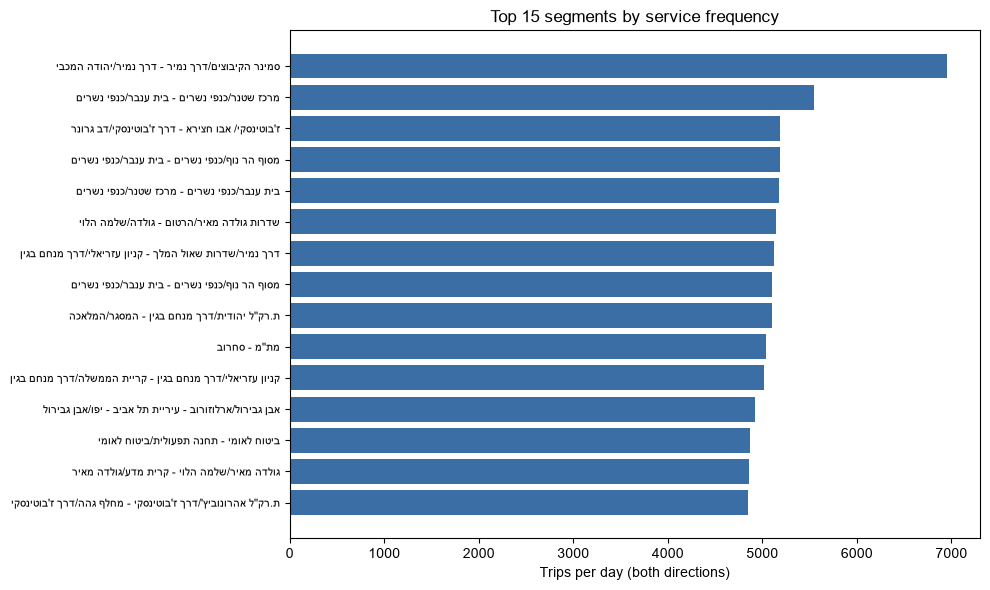

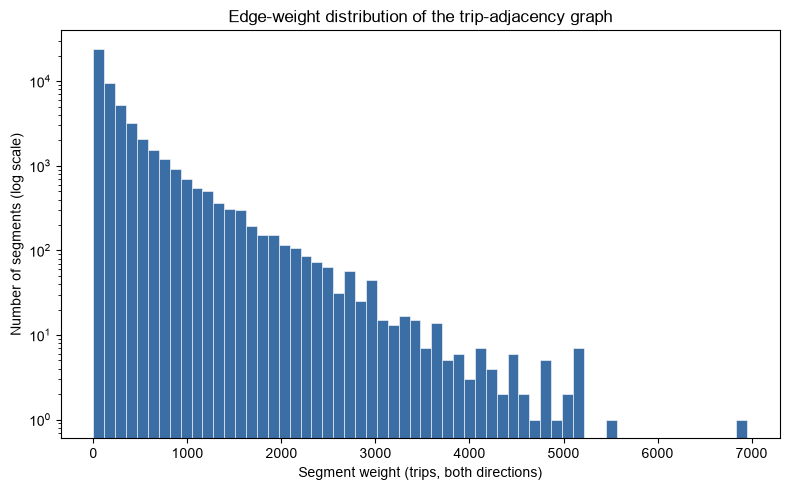

Edge weight percentiles:
count    51772.00
mean       295.35
std        450.18
min          1.00
50%        134.50
90%        780.00
99%       2197.29
max       6955.00


In [11]:
TOP_N = 15

name_of = {n: (G.nodes[n].get("stop_name") or n) for n in G.nodes()}
top = sorted(G.edges(data=True), key=lambda e: e[2]["weight"], reverse=True)[:TOP_N]
top_df = pd.DataFrame([
    {"stop_a": u, "stop_b": v,
     "name_a": name_of[u], "name_b": name_of[v],
     "trips_both_directions": d["weight"]}
    for u, v, d in top
])
top_df.to_csv(TABLES / "top_segments.csv", index=False, encoding="utf-8-sig")
display(top_df)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r.name_a} - {r.name_b}" for r in top_df.itertuples()][::-1]
ax.barh(range(len(top_df)), top_df["trips_both_directions"][::-1], color="#3b6ea5")
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Trips per day (both directions)")
ax.set_title(f"Top {TOP_N} segments by service frequency")
fig.tight_layout()
fig.savefig(FIGURES / "top_segments.png", dpi=150)
plt.show()

weights = [d["weight"] for _, _, d in G.edges(data=True)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(weights, bins=60, log=True, color="#3b6ea5", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Segment weight (trips, both directions)")
ax.set_ylabel("Number of segments (log scale)")
ax.set_title("Edge-weight distribution of the trip-adjacency graph")
fig.tight_layout()
fig.savefig(FIGURES / "weight_distribution.png", dpi=150)
plt.show()

ws = pd.Series(weights)
print("Edge weight percentiles:")
print(ws.describe(percentiles=[0.5, 0.9, 0.99]).round(2).to_string())

## Conclusions

The streaming build produces the sparse trip-adjacency structure we expected: about 30.5 thousand nodes, about 52 thousand directed segments (roughly 51.8 thousand after undirected projection), an average undirected degree near 3.4, and density around $1.1 \times 10^{-4}$. Those numbers come from about 15.7 million stop-time rows and about 420 thousand trips. This is a corridor network with relatively few distinct neighbors per stop, even though many scheduled trips can reuse the same connection.

The order checks give us an important qualification. There are zero interleaved trip blocks, so a trip does not disappear and later reappear in the stream. The full pass records 562 local `stop_sequence` regressions among roughly 15.7 million rows, about 0.004%. That is a very small fraction, but it means the file is not perfectly increasing within every trip, so any edges immediately around those rows inherit that local ordering issue. We keep the exact counters in `graph_build_summary.json` rather than treating the ordering as flawless.

Only about three scheduled stop identifiers fail to become nodes because they never participate in a non-self segment. This small gap follows from our definition of $V$ and is now explicit. The projection assertions also confirm that directed and undirected graphs share their node set and that opposite-direction frequencies were combined correctly.

The weight distribution is strongly right-skewed: most distinct segments have single-digit scheduled counts, while a small group carries orders of magnitude more service. The named high-frequency segments are concentrated in major Tel Aviv-area corridors, which is consistent with the service composition and geography already visible in the feed.

Most importantly, the weight is scheduled frequency, not ridership, passenger capacity, distance, or travel time. A high-weight connection is heavily supplied in this timetable; we cannot infer how many people actually use it. All later importance and resilience results need to stay within that supply-network interpretation.